In [1]:
# ─────────────────────────────────────────────────────────────
# NB04 — ConvNeXt-Nano Two-Stage ABMIL Training (PyTorch)
# Structure mirrors NB03 exactly — only backbone changes
# ─────────────────────────────────────────────────────────────
import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm
from sklearn.metrics import (
    f1_score, recall_score, roc_auc_score,
    roc_curve, confusion_matrix
)
from sklearn.calibration import calibration_curve

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print(f"timm    : {timm.__version__}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

PyTorch : 2.10.0+cu128
CUDA    : True
timm    : 1.0.26
GPU     : Tesla T4


In [2]:
# ─────────────────────────────────────────────────────────────
# Paths — NB02 outputs reused, new outputs saved to working dir
# ─────────────────────────────────────────────────────────────
NB02 = Path("/kaggle/input/notebooks/mfjmrizvi/02-mil-patch-extraction")
OUT  = Path("/kaggle/working")

X_TRAIN_PATH      = NB02 / "X_train_patches.npy"
Y_TRAIN_PATH      = NB02 / "y_train_labels.npy"
BAG_IDS_TRAIN_PATH= NB02 / "bag_ids_train.npy"
TRAIN_BAG_IDX_PATH= NB02 / "train_bag_indices.npy"
VAL_BAG_IDX_PATH  = NB02 / "val_bag_indices.npy"
CLASS_WEIGHTS_PATH= NB02 / "class_weights.json"
X_TEST_PATH       = NB02 / "X_test_patches.npy"
Y_TEST_PATH       = NB02 / "y_test_labels.npy"
BAG_IDS_TEST_PATH = NB02 / "bag_ids_test.npy"

S1_WEIGHTS   = OUT / "convnext_nano_stage1.pth"
S2_WEIGHTS   = OUT / "convnext_nano_stage2.pth"
RESULTS_JSON = OUT / "convnext_nano_results.json"

print("NB02 path exists:", NB02.exists())
print("Output dir      :", OUT)

NB02 path exists: True
Output dir      : /kaggle/working


In [3]:
# ─────────────────────────────────────────────────────────────
# Hyperparameters
# FEAT_DIM is confirmed by dummy forward pass below — do NOT
# hardcode until you have seen the printed value
# ─────────────────────────────────────────────────────────────
MODEL_NAME = "convnext_nano"
ATTN_DIM   = 128
PATCH_SIZE = 224
SEED       = 42

# Stage 1
BS_STAGE1  = 128
LR_STAGE1  = 1e-3
EPOCHS_S1  = 15
PATIENCE_S1= 5

# Stage 2
LR_S2_HEAD = 1e-4
EPOCHS_S2  = 30
PATIENCE_S2= 7

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cuda


In [4]:
# ─────────────────────────────────────────────────────────────
# Build backbone and confirm feature dimension
# This must run before FEAT_DIM is used anywhere
# ─────────────────────────────────────────────────────────────
def build_backbone(model_name: str,
                   pretrained: bool = True) -> nn.Module:
    model = timm.create_model(
        model_name,
        pretrained=pretrained,
        num_classes=0   # removes classifier head, keeps GAP
    )
    return model

backbone = build_backbone(MODEL_NAME, pretrained=True).to(DEVICE)

with torch.no_grad():
    _dummy = torch.zeros(2, 3, PATCH_SIZE, PATCH_SIZE,
                         device=DEVICE)
    _out   = backbone(_dummy)
    FEAT_DIM = _out.shape[1]
    print(f"Backbone output shape : {_out.shape}")
    print(f"FEAT_DIM confirmed    : {FEAT_DIM}")
del _dummy, _out
print("Backbone verified.")

model.safetensors:   0%|          | 0.00/62.4M [00:00<?, ?B/s]

Backbone output shape : torch.Size([2, 640])
FEAT_DIM confirmed    : 640
Backbone verified.


In [5]:
# ─────────────────────────────────────────────────────────────
# Load NB02 outputs
# ─────────────────────────────────────────────────────────────
print("Loading arrays...")
X_train_all       = np.load(X_TRAIN_PATH)
y_train_all       = np.load(Y_TRAIN_PATH)
bag_ids_all       = np.load(BAG_IDS_TRAIN_PATH)
train_bag_indices = np.load(TRAIN_BAG_IDX_PATH)
val_bag_indices   = np.load(VAL_BAG_IDX_PATH)
X_test_all        = np.load(X_TEST_PATH)
y_test_all        = np.load(Y_TEST_PATH)
bag_ids_test      = np.load(BAG_IDS_TEST_PATH)

with open(CLASS_WEIGHTS_PATH) as f:
    raw_cw = json.load(f)
class_weight_dict = {int(k): float(v) for k, v in raw_cw.items()}

print(f"X_train_all : {X_train_all.shape}  dtype={X_train_all.dtype}")
print(f"y_train_all : unique={np.unique(y_train_all)}  "
      f"benign={(y_train_all==0).sum()}  "
      f"malignant={(y_train_all==1).sum()}")
overlap = set(train_bag_indices) & set(val_bag_indices)
print(f"Patient overlap : {len(overlap)}  (must be 0)")
print(f"Class weights   : {class_weight_dict}")

Loading arrays...
X_train_all : (19770, 224, 224, 1)  dtype=float32
y_train_all : unique=[0 1]  benign=13616  malignant=6154
Patient overlap : 0  (must be 0)
Class weights   : {0: 0.7259841363102233, 1: 1.6062723431914203}


In [6]:
# ─────────────────────────────────────────────────────────────
# Split patches using precomputed patient-level bag indices
# ─────────────────────────────────────────────────────────────
train_mask = np.isin(bag_ids_all, train_bag_indices)
val_mask   = np.isin(bag_ids_all, val_bag_indices)

X_tr    = X_train_all[train_mask]
y_tr    = y_train_all[train_mask]
bag_tr  = bag_ids_all[train_mask]

X_val   = X_train_all[val_mask]
y_val   = y_train_all[val_mask]
bag_val = bag_ids_all[val_mask]

print(f"Train patches : {X_tr.shape}  "
      f"benign={(y_tr==0).sum()}  malignant={(y_tr==1).sum()}")
print(f"Val patches   : {X_val.shape}  "
      f"benign={(y_val==0).sum()}  malignant={(y_val==1).sum()}")
print(f"Train bags    : {len(np.unique(bag_tr))}")
print(f"Val bags      : {len(np.unique(bag_val))}")

Train patches : (16198, 224, 224, 1)  benign=11356  malignant=4842
Val patches   : (3572, 224, 224, 1)  benign=2260  malignant=1312
Train bags    : 1061
Val bags      : 257


In [9]:
# ─────────────────────────────────────────────────────────────
# Normalisation tensors (CPU) — used inside Dataset __getitem__
# ─────────────────────────────────────────────────────────────
_mean_cpu = torch.tensor(IMAGENET_MEAN, dtype=torch.float32).view(3,1,1)
_std_cpu  = torch.tensor(IMAGENET_STD,  dtype=torch.float32).view(3,1,1)

# GPU tensors — used in extract_features
_mean_gpu = torch.tensor(IMAGENET_MEAN, dtype=torch.float32,
                         device=DEVICE).view(1,3,1,1)
_std_gpu  = torch.tensor(IMAGENET_STD,  dtype=torch.float32,
                         device=DEVICE).view(1,3,1,1)

def numpy_to_tensor(X_np: np.ndarray) -> torch.Tensor:
    """(N,224,224,1) float32 → (N,3,224,224) normalised on GPU."""
    t = torch.from_numpy(X_np).float()
    t = t.permute(0, 3, 1, 2).repeat(1, 3, 1, 1).to(DEVICE)
    return (t - _mean_gpu) / _std_gpu

In [10]:
# ─────────────────────────────────────────────────────────────
# Datasets
# ─────────────────────────────────────────────────────────────
class PatchDataset(Dataset):
    def __init__(self, X_np, y_np):
        self.X = X_np
        self.y = torch.from_numpy(y_np).float()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        patch = torch.from_numpy(self.X[idx]).float()  # (224,224,1)
        patch = patch.permute(2, 0, 1).repeat(3, 1, 1) # (3,224,224)
        patch = (patch - _mean_cpu) / _std_cpu
        return patch, self.y[idx]


class CachedBagDataset(Dataset):
    def __init__(self, features, y_np, bag_ids, bag_list):
        self.features = features
        self.y        = y_np
        self.bag_ids  = bag_ids
        self.bag_list = bag_list

    def __len__(self):
        return len(self.bag_list)

    def __getitem__(self, idx):
        bid  = self.bag_list[idx]
        mask = self.bag_ids == bid
        h    = torch.from_numpy(self.features[mask]).float()
        bag_label = torch.tensor(self.y[mask][0], dtype=torch.float32)
        return h, bag_label


def collate_cached(batch):
    return [item[0] for item in batch], \
           torch.stack([item[1] for item in batch])

In [11]:
# ─────────────────────────────────────────────────────────────
# Model components — identical to NB03
# ─────────────────────────────────────────────────────────────
class PatchClassifier(nn.Module):
    def __init__(self, backbone, feat_dim):
        super().__init__()
        self.backbone = backbone
        self.head     = nn.Linear(feat_dim, 1)

    def forward(self, x):
        return self.head(self.backbone(x)).squeeze(1)


class AttentionPool(nn.Module):
    def __init__(self, feat_dim, attn_dim):
        super().__init__()
        self.V = nn.Linear(feat_dim, attn_dim, bias=True)
        self.w = nn.Linear(attn_dim, 1,        bias=False)

    def forward(self, h):
        a = torch.softmax(self.w(torch.tanh(self.V(h))), dim=0)
        z = torch.sum(a * h, dim=0, keepdim=True)
        return z, a


class BagClassifier(nn.Module):
    def __init__(self, feat_dim, attn_dim):
        super().__init__()
        self.attn = AttentionPool(feat_dim, attn_dim)
        self.head = nn.Linear(feat_dim, 1)

    def forward(self, h):
        z, a = self.attn(h)
        return self.head(z).squeeze(), a

In [12]:
# ─────────────────────────────────────────────────────────────
# Stage 1 setup
# ─────────────────────────────────────────────────────────────
patch_model = PatchClassifier(backbone, FEAT_DIM).to(DEVICE)

pos_weight_val = class_weight_dict[1] / class_weight_dict[0]
criterion_s1   = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight_val, device=DEVICE)
)
print(f"pos_weight : {pos_weight_val:.4f}")

optimiser_s1 = optim.Adam(patch_model.parameters(), lr=LR_STAGE1)
scheduler_s1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimiser_s1, mode='min', factor=0.5, patience=3
)

train_patch_dl = DataLoader(
    PatchDataset(X_tr, y_tr),
    batch_size=BS_STAGE1, shuffle=True,
    num_workers=2, pin_memory=True
)
val_patch_dl = DataLoader(
    PatchDataset(X_val, y_val),
    batch_size=BS_STAGE1, shuffle=False,
    num_workers=2, pin_memory=True
)
print(f"Train batches : {len(train_patch_dl)}")
print(f"Val batches   : {len(val_patch_dl)}")

pos_weight : 2.2125
Train batches : 127
Val batches   : 28


In [13]:
# ─────────────────────────────────────────────────────────────
# Stage 1 training loop
# ─────────────────────────────────────────────────────────────
s1_history = {"train_loss": [], "val_loss": [],
              "val_auc": [],    "val_f1":  []}
best_val_loss_s1   = float("inf")
patience_counter_s1 = 0
t0 = time.time()

for epoch in range(1, EPOCHS_S1 + 1):
    # Train
    patch_model.train()
    running_loss = 0.0
    for patches, labels in train_patch_dl:
        patches, labels = patches.to(DEVICE), labels.to(DEVICE)
        optimiser_s1.zero_grad()
        loss = criterion_s1(patch_model(patches), labels)
        loss.backward()
        optimiser_s1.step()
        running_loss += loss.item() * len(labels)
    train_loss = running_loss / len(train_patch_dl.dataset)

    # Validate
    patch_model.eval()
    val_loss, all_probs, all_labels = 0.0, [], []
    with torch.no_grad():
        for patches, labels in val_patch_dl:
            patches, labels = patches.to(DEVICE), labels.to(DEVICE)
            logits = patch_model(patches)
            val_loss += criterion_s1(logits, labels).item() * len(labels)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    val_loss   /= len(val_patch_dl.dataset)
    all_probs   = np.array(all_probs)
    all_labels  = np.array(all_labels)
    val_preds   = (all_probs >= 0.5).astype(int)
    val_auc     = roc_auc_score(all_labels, all_probs)
    val_f1      = f1_score(all_labels, val_preds, zero_division=0)

    s1_history["train_loss"].append(train_loss)
    s1_history["val_loss"].append(val_loss)
    s1_history["val_auc"].append(val_auc)
    s1_history["val_f1"].append(val_f1)
    scheduler_s1.step(val_loss)

    print(f"Ep {epoch:02d}/{EPOCHS_S1}  "
          f"train={train_loss:.4f}  val={val_loss:.4f}  "
          f"auc={val_auc:.4f}  f1={val_f1:.4f}")

    if val_loss < best_val_loss_s1:
        best_val_loss_s1    = val_loss
        patience_counter_s1 = 0
        torch.save(patch_model.state_dict(), S1_WEIGHTS)
        print("  ✓ Saved best Stage 1 weights")
    else:
        patience_counter_s1 += 1
        if patience_counter_s1 >= PATIENCE_S1:
            print(f"  Early stopping at epoch {epoch}")
            break

print(f"\nStage 1 complete — {(time.time()-t0)/60:.1f} min")

Ep 01/15  train=1.0352  val=0.9236  auc=0.6708  f1=0.5494
  ✓ Saved best Stage 1 weights
Ep 02/15  train=0.8468  val=0.9512  auc=0.6359  f1=0.3919
Ep 03/15  train=0.8357  val=0.9128  auc=0.6900  f1=0.5549
  ✓ Saved best Stage 1 weights
Ep 04/15  train=0.8496  val=0.9045  auc=0.6820  f1=0.5337
  ✓ Saved best Stage 1 weights
Ep 05/15  train=0.8013  val=0.8480  auc=0.6974  f1=0.5520
  ✓ Saved best Stage 1 weights
Ep 06/15  train=0.7811  val=0.8957  auc=0.7061  f1=0.5464
Ep 07/15  train=0.7574  val=0.8657  auc=0.6987  f1=0.5389
Ep 08/15  train=0.7425  val=0.8744  auc=0.7222  f1=0.5806
Ep 09/15  train=0.7332  val=0.8479  auc=0.7256  f1=0.5853
  ✓ Saved best Stage 1 weights
Ep 10/15  train=0.7196  val=0.8172  auc=0.7126  f1=0.5732
  ✓ Saved best Stage 1 weights
Ep 11/15  train=0.7111  val=0.8132  auc=0.7115  f1=0.5552
  ✓ Saved best Stage 1 weights
Ep 12/15  train=0.7095  val=0.8404  auc=0.7205  f1=0.5736
Ep 13/15  train=0.7098  val=0.8286  auc=0.7157  f1=0.5725
Ep 14/15  train=0.7065  val=0

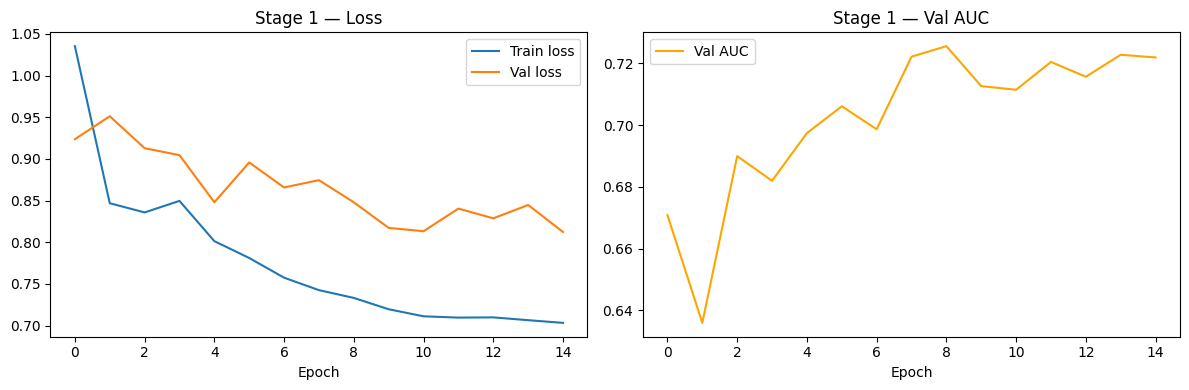

Saved convnext_nano_stage1_curves.png


In [15]:
# Stage 1 curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(s1_history["train_loss"], label="Train loss")
axes[0].plot(s1_history["val_loss"],   label="Val loss")
axes[0].set_title("Stage 1 — Loss");     axes[0].legend()
axes[0].set_xlabel("Epoch")
axes[1].plot(s1_history["val_auc"], color="orange", label="Val AUC")
axes[1].set_title("Stage 1 — Val AUC"); axes[1].legend()
axes[1].set_xlabel("Epoch")
plt.tight_layout()
plt.savefig(OUT / "convnext_nano_stage1_curves.png", dpi=150)
plt.show()
print("Saved convnext_nano_stage1_curves.png")

In [16]:
# ─────────────────────────────────────────────────────────────
# Stage 1 patch-level diagnostic metrics
# ─────────────────────────────────────────────────────────────
patch_model.load_state_dict(
    torch.load(S1_WEIGHTS, map_location=DEVICE))
patch_model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for patches, labels in val_patch_dl:
        patches = patches.to(DEVICE)
        all_probs.extend(
            torch.sigmoid(patch_model(patches)).cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
preds      = (all_probs >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(all_labels, preds).ravel()

s1_metrics = {
    "patch_auc"        : float(roc_auc_score(all_labels, all_probs)),
    "patch_f1"         : float(f1_score(all_labels, preds,
                                         zero_division=0)),
    "patch_sensitivity": float(recall_score(all_labels, preds,
                                             zero_division=0)),
    "patch_specificity": float(tn / (tn + fp)),
}
print("── Stage 1 Patch-Level Val Metrics ──")
for k, v in s1_metrics.items():
    print(f"  {k:25s}: {v:.4f}")

── Stage 1 Patch-Level Val Metrics ──
  patch_auc                : 0.7219
  patch_f1                 : 0.5784
  patch_sensitivity        : 0.4611
  patch_specificity        : 0.9226


In [17]:
# ─────────────────────────────────────────────────────────────
# Feature extraction — backbone frozen, features cached once
# ─────────────────────────────────────────────────────────────
feature_extractor = patch_model.backbone
feature_extractor.eval()
for p in feature_extractor.parameters():
    p.requires_grad_(False)

def extract_features(X_np, model, batch_size=256):
    all_feats = []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(X_np), batch_size):
            t     = numpy_to_tensor(X_np[start:start+batch_size])
            feats = model(t).cpu().numpy()
            all_feats.append(feats)
    return np.concatenate(all_feats, axis=0)

print("Extracting train features...")
feats_tr   = extract_features(X_tr,       feature_extractor)
print(f"  train : {feats_tr.shape}")

print("Extracting val features...")
feats_val  = extract_features(X_val,      feature_extractor)
print(f"  val   : {feats_val.shape}")

print("Extracting test features...")
feats_test = extract_features(X_test_all, feature_extractor)
print(f"  test  : {feats_test.shape}")

Extracting train features...
  train : (16198, 640)
Extracting val features...
  val   : (3572, 640)
Extracting test features...
  test  : (5997, 640)


In [18]:
# ─────────────────────────────────────────────────────────────
# Stage 2 setup
# ─────────────────────────────────────────────────────────────
bag_model    = BagClassifier(FEAT_DIM, ATTN_DIM).to(DEVICE)
criterion_s2 = nn.BCEWithLogitsLoss()
optimiser_s2 = optim.Adam(bag_model.parameters(), lr=LR_S2_HEAD)
scheduler_s2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimiser_s2, mode='min', factor=0.5, patience=3
)

def get_bag_labels(y_np, bag_ids, bag_list):
    return np.array([int(y_np[bag_ids == b][0]) for b in bag_list])

train_bag_ds = CachedBagDataset(feats_tr,   y_tr,       bag_tr,       train_bag_indices)
val_bag_ds   = CachedBagDataset(feats_val,  y_val,      bag_val,      val_bag_indices)

train_bag_dl = DataLoader(train_bag_ds, batch_size=1,
                          shuffle=True,  collate_fn=collate_cached)
val_bag_dl   = DataLoader(val_bag_ds,   batch_size=1,
                          shuffle=False, collate_fn=collate_cached)

print(f"Train bags : {len(train_bag_ds)}")
print(f"Val bags   : {len(val_bag_ds)}")

Train bags : 1061
Val bags   : 257


In [19]:
# ─────────────────────────────────────────────────────────────
# Stage 2 training loop
# ─────────────────────────────────────────────────────────────
s2_history = {"train_loss": [], "val_loss": [],
              "val_auc": [],    "val_f1":  []}
best_val_loss_s2    = float("inf")
patience_counter_s2 = 0
t0 = time.time()

for epoch in range(1, EPOCHS_S2 + 1):
    # Train
    bag_model.train()
    running_loss = 0.0
    for h_list, labels in train_bag_dl:
        h     = h_list[0].to(DEVICE)
        label = labels[0].to(DEVICE)
        optimiser_s2.zero_grad()
        logit, _ = bag_model(h)
        loss = criterion_s2(logit, label)
        loss.backward()
        optimiser_s2.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_bag_ds)

    # Validate
    bag_model.eval()
    val_loss, val_probs, val_true = 0.0, [], []
    with torch.no_grad():
        for h_list, labels in val_bag_dl:
            h     = h_list[0].to(DEVICE)
            label = labels[0].to(DEVICE)
            logit, _ = bag_model(h)
            val_loss += criterion_s2(logit, label).item()
            val_probs.append(torch.sigmoid(logit).item())
            val_true.append(label.item())
    val_loss  /= len(val_bag_ds)
    val_probs  = np.array(val_probs)
    val_true   = np.array(val_true)
    val_preds  = (val_probs >= 0.5).astype(int)
    val_auc    = roc_auc_score(val_true, val_probs)
    val_f1     = f1_score(val_true, val_preds, zero_division=0)

    s2_history["train_loss"].append(train_loss)
    s2_history["val_loss"].append(val_loss)
    s2_history["val_auc"].append(val_auc)
    s2_history["val_f1"].append(val_f1)
    scheduler_s2.step(val_loss)

    print(f"Ep {epoch:02d}/{EPOCHS_S2}  "
          f"train={train_loss:.4f}  val={val_loss:.4f}  "
          f"auc={val_auc:.4f}  f1={val_f1:.4f}")

    if val_loss < best_val_loss_s2:
        best_val_loss_s2    = val_loss
        patience_counter_s2 = 0
        torch.save(bag_model.state_dict(), S2_WEIGHTS)
        print("  ✓ Saved best Stage 2 weights")
    else:
        patience_counter_s2 += 1
        if patience_counter_s2 >= PATIENCE_S2:
            print(f"  Early stopping at epoch {epoch}")
            break

print(f"\nStage 2 complete — {(time.time()-t0)/60:.1f} min")

Ep 01/30  train=0.2565  val=0.2086  auc=0.9754  f1=0.9225
  ✓ Saved best Stage 2 weights
Ep 02/30  train=0.1010  val=0.1802  auc=0.9753  f1=0.9343
  ✓ Saved best Stage 2 weights
Ep 03/30  train=0.0764  val=0.1997  auc=0.9778  f1=0.9338
Ep 04/30  train=0.0655  val=0.1915  auc=0.9780  f1=0.9304
Ep 05/30  train=0.0620  val=0.1838  auc=0.9779  f1=0.9386
Ep 06/30  train=0.0571  val=0.1830  auc=0.9779  f1=0.9424
Ep 07/30  train=0.0486  val=0.1889  auc=0.9778  f1=0.9462
Ep 08/30  train=0.0525  val=0.1978  auc=0.9789  f1=0.9386
Ep 09/30  train=0.0495  val=0.1890  auc=0.9779  f1=0.9462
  Early stopping at epoch 9

Stage 2 complete — 0.3 min


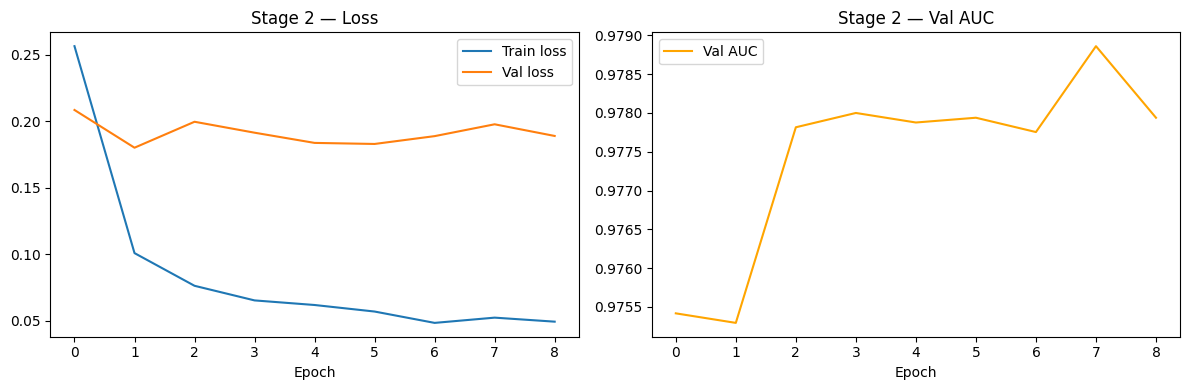

In [20]:
# Stage 2 curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(s2_history["train_loss"], label="Train loss")
axes[0].plot(s2_history["val_loss"],   label="Val loss")
axes[0].set_title("Stage 2 — Loss");     axes[0].legend()
axes[0].set_xlabel("Epoch")
axes[1].plot(s2_history["val_auc"], color="orange", label="Val AUC")
axes[1].set_title("Stage 2 — Val AUC"); axes[1].legend()
axes[1].set_xlabel("Epoch")
plt.tight_layout()
plt.savefig(OUT / "convnext_nano_stage2_curves.png", dpi=150)
plt.show()

In [21]:
# ─────────────────────────────────────────────────────────────
# Val bag-level evaluation and threshold calibration
# ─────────────────────────────────────────────────────────────
bag_model.load_state_dict(
    torch.load(S2_WEIGHTS, map_location=DEVICE))
bag_model.eval()

val_bag_probs, val_bag_true = [], []
with torch.no_grad():
    for h_list, labels in val_bag_dl:
        h = h_list[0].to(DEVICE)
        logit, _ = bag_model(h)
        val_bag_probs.append(torch.sigmoid(logit).item())
        val_bag_true.append(labels[0].item())

val_bag_probs = np.array(val_bag_probs)
val_bag_true  = np.array(val_bag_true)

print(f"Val bags          : {len(val_bag_probs)}")
print(f"benign={( val_bag_true==0).sum()}  "
      f"malignant={(val_bag_true==1).sum()}")

fpr_c, tpr_c, thresholds_c = roc_curve(val_bag_true, val_bag_probs)
idx = np.argmax(tpr_c >= 0.90)
optimal_threshold = float(thresholds_c[idx])
print(f"Calibrated threshold : {optimal_threshold:.4f}")
print(f"Sensitivity at cal.  : {tpr_c[idx]:.4f}")
print(f"FPR at cal.          : {fpr_c[idx]:.4f}")

Val bags          : 257
benign=113  malignant=144
Calibrated threshold : 0.3291
Sensitivity at cal.  : 0.9306
FPR at cal.          : 0.0265


In [22]:
# ─────────────────────────────────────────────────────────────
# Metrics helper — identical to NB03
# ─────────────────────────────────────────────────────────────
def compute_all_metrics(y_true, y_probs, threshold, label=""):
    y_pred = (y_probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fpr_val     = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    prob_true, prob_pred = calibration_curve(
        y_true, y_probs, n_bins=10, strategy='uniform')
    bin_counts = np.histogram(y_probs, bins=np.linspace(0,1,11))[0]
    ece = float(np.sum(
        bin_counts[:len(prob_true)] * np.abs(prob_true - prob_pred)
    ) / len(y_probs))

    metrics = {
        "threshold"  : threshold,
        "auc"        : float(roc_auc_score(y_true, y_probs)),
        "f1"         : float(f1_score(y_true, y_pred, zero_division=0)),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "fpr"        : float(fpr_val),
        "ece"        : ece,
    }
    if label:
        print(f"── {label} ──")
        for k, v in metrics.items():
            print(f"  {k:15s}: {v:.4f}")
    return metrics

val_metrics_default = compute_all_metrics(
    val_bag_true, val_bag_probs, 0.5,
    "Val — default threshold (0.5)")
print()
val_metrics_cal = compute_all_metrics(
    val_bag_true, val_bag_probs, optimal_threshold,
    f"Val — calibrated threshold ({optimal_threshold:.3f})")

── Val — default threshold (0.5) ──
  threshold      : 0.5000
  auc            : 0.9753
  f1             : 0.9343
  sensitivity    : 0.8889
  specificity    : 0.9823
  fpr            : 0.0177
  ece            : 0.0295

── Val — calibrated threshold (0.329) ──
  threshold      : 0.3291
  auc            : 0.9753
  f1             : 0.9537
  sensitivity    : 0.9306
  specificity    : 0.9735
  fpr            : 0.0265
  ece            : 0.0295


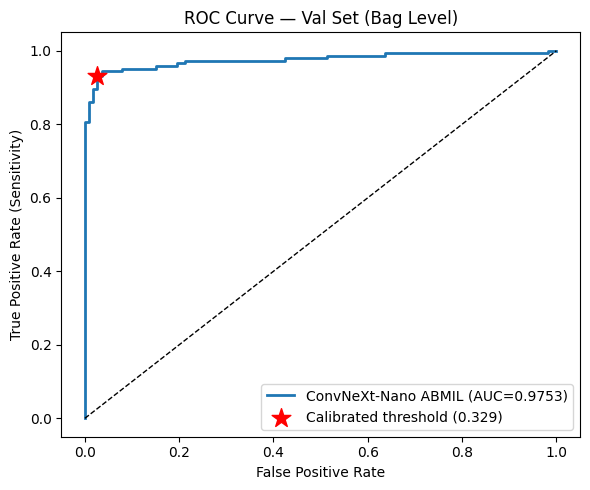

In [23]:
# ROC curve plot
fpr_r, tpr_r, _ = roc_curve(val_bag_true, val_bag_probs)
auc_val = roc_auc_score(val_bag_true, val_bag_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr_r, tpr_r, lw=2,
         label=f"ConvNeXt-Nano ABMIL (AUC={auc_val:.4f})")
plt.scatter([fpr_c[idx]], [tpr_c[idx]], marker='*', s=200,
            color='red', zorder=5,
            label=f"Calibrated threshold ({optimal_threshold:.3f})")
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve — Val Set (Bag Level)")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "convnext_nano_roc_curve.png", dpi=150)
plt.show()

In [24]:
# ─────────────────────────────────────────────────────────────
# Test set — touched once, threshold fixed from val
# ─────────────────────────────────────────────────────────────
test_bag_list = np.unique(bag_ids_test)
test_bag_ds   = CachedBagDataset(feats_test, y_test_all,
                                  bag_ids_test, test_bag_list)
test_bag_dl   = DataLoader(test_bag_ds, batch_size=1,
                            shuffle=False, collate_fn=collate_cached)

test_bag_probs, test_bag_true = [], []
bag_model.eval()
with torch.no_grad():
    for h_list, labels in test_bag_dl:
        h = h_list[0].to(DEVICE)
        logit, _ = bag_model(h)
        test_bag_probs.append(torch.sigmoid(logit).item())
        test_bag_true.append(labels[0].item())

test_bag_probs = np.array(test_bag_probs)
test_bag_true  = np.array(test_bag_true)

test_metrics = compute_all_metrics(
    test_bag_true, test_bag_probs, optimal_threshold,
    f"Test — calibrated threshold ({optimal_threshold:.3f})")

── Test — calibrated threshold (0.329) ──
  threshold      : 0.3291
  auc            : 0.9925
  f1             : 0.9316
  sensitivity    : 0.9728
  specificity    : 0.9264
  fpr            : 0.0736
  ece            : 0.0524


In [25]:
# ─────────────────────────────────────────────────────────────
# Save results JSON
# ─────────────────────────────────────────────────────────────
results = {
    "model"              : MODEL_NAME,
    "feat_dim"           : FEAT_DIM,
    "attn_dim"           : ATTN_DIM,
    "stage1_metrics"     : s1_metrics,
    "val_metrics_default": val_metrics_default,
    "val_metrics_cal"    : val_metrics_cal,
    "test_metrics"       : test_metrics,
    "optimal_threshold"  : optimal_threshold,
    "hyperparameters"    : {
        "lr_stage1"  : LR_STAGE1,
        "lr_s2_head" : LR_S2_HEAD,
        "epochs_s1"  : EPOCHS_S1,
        "epochs_s2"  : EPOCHS_S2,
        "bs_stage1"  : BS_STAGE1,
        "attn_dim"   : ATTN_DIM,
        "patience_s1": PATIENCE_S1,
        "patience_s2": PATIENCE_S2,
    }
}
with open(RESULTS_JSON, "w") as f:
    json.dump(results, f, indent=2)
print("Saved:", RESULTS_JSON)

Saved: /kaggle/working/convnext_nano_results.json


In [26]:
# ─────────────────────────────────────────────────────────────
# Final summary printout
# ─────────────────────────────────────────────────────────────
print("=" * 55)
print(f"  NB04 — {MODEL_NAME.upper()} ABMIL — FINAL RESULTS")
print("=" * 55)
print(f"  FEAT_DIM confirmed     : {FEAT_DIM}")
print(f"  Stage 1 patch AUC      : {s1_metrics['patch_auc']:.4f}")
print(f"  Optimal threshold      : {optimal_threshold:.4f}")
print()
print("  Val set (calibrated threshold):")
for k in ["auc","f1","sensitivity","fpr","ece"]:
    print(f"    {k:15s}: {val_metrics_cal[k]:.4f}")
print()
print("  Test set (calibrated threshold):")
for k in ["auc","f1","sensitivity","fpr","ece"]:
    print(f"    {k:15s}: {test_metrics[k]:.4f}")
print("=" * 55)

  NB04 — CONVNEXT_NANO ABMIL — FINAL RESULTS
  FEAT_DIM confirmed     : 640
  Stage 1 patch AUC      : 0.7219
  Optimal threshold      : 0.3291

  Val set (calibrated threshold):
    auc            : 0.9753
    f1             : 0.9537
    sensitivity    : 0.9306
    fpr            : 0.0265
    ece            : 0.0295

  Test set (calibrated threshold):
    auc            : 0.9925
    f1             : 0.9316
    sensitivity    : 0.9728
    fpr            : 0.0736
    ece            : 0.0524
